## Group: [153] Italienerne
#### Authors:
- Riccardo Mazzoleni    152564
- Simone Tolledi        151684
- Samrath Singh Chhabra 152583

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

from prophet import Prophet

In [42]:
receivals = pd.read_csv('receivals.csv')
purchase_orders = pd.read_csv("purchase_orders.csv")

#### Data and Preprocessing

In [43]:
def clean_receivals(df: pd.DataFrame, start_date="2010-01-01") -> pd.DataFrame:
    
    df = df.dropna(subset=["rm_id","date_arrival", "net_weight"])
    df['date_arrival'] = pd.to_datetime(df['date_arrival'], utc=True)

    df = df[df["date_arrival"] >= pd.Timestamp(start_date, tz="UTC")]

    keep_cols = ["rm_id", "product_id", "date_arrival", "net_weight"]
    return df[keep_cols]

def clean_purchase_orders(df: pd.DataFrame) -> pd.DataFrame:
    df["delivery_date"] = pd.to_datetime(df["delivery_date"], errors="coerce", utc=True)
    df["delivery_date"] = pd.to_datetime(df["delivery_date"]).dt.date
    df = df.dropna(subset=["purchase_order_id", "delivery_date", "quantity"])
    keep_cols = ["delivery_date", "product_id", "quantity"]
    return df[keep_cols]

def aggregate_daily_weight(df: pd.DataFrame) -> pd.DataFrame:
    df["date"] = df["date_arrival"].dt.floor("D")

    df_agg = (
        df.groupby(["rm_id", "date"], as_index=False)["net_weight"]
        .sum()
        .rename(columns={"net_weight": "daily_weight"})
    )
    prod_map = df.groupby("rm_id")["product_id"].first()
    df_agg["product_id"] = df_agg["rm_id"].map(prod_map)
    return df_agg

def make_continuous_timeseries(df: pd.DataFrame, start_date, end_date) -> pd.DataFrame:
    prod_map = df.groupby("rm_id")["product_id"].first()
    all_rms = df["rm_id"].unique()
    all_dates = pd.date_range(start=start_date, end=end_date, freq="D", tz="UTC")
    
    full_index = pd.MultiIndex.from_product([all_rms, all_dates], names=["rm_id", "date"])
    df = df.set_index(["rm_id", "date"]).reindex(full_index).reset_index()
    

    df["product_id"] = df["rm_id"].map(prod_map)

    df["daily_weight"] = df["daily_weight"].fillna(0)
    df["date"] = pd.to_datetime(df["date"]).dt.date
    
    
    return df

def aggregate_order_quantity(df: pd.DataFrame) -> pd.DataFrame:
    df_agg = (
        df.groupby(["delivery_date", "product_id"])["quantity"]
        .sum()
        .reset_index()
        .rename(columns={"delivery_date": "date", "quantity": "quantity_ordered"})
    )

    return df_agg


def merge_orders_timeseries(timeseries_df: pd.DataFrame, orders_agg_df: pd.DataFrame) -> pd.DataFrame:
    final_df = pd.merge(
        timeseries_df,
        orders_agg_df,
        on=["date", "product_id"],
        how="left"
    )
    final_df["quantity_ordered"] = final_df["quantity_ordered"].fillna(0)
    
    final_df["date"] = pd.to_datetime(final_df["date"])

    keep_cols = ["rm_id", "product_id", "date", "daily_weight", "quantity_ordered"]
    return final_df[keep_cols]


In [44]:
#we don't use this definitions in this program, we tried to use it but it doesn't work (prophet doesn't need that much feature engineering)
def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["year"] = df["date"].dt.year
    df["cum_weight"] = df.groupby(['rm_id','year'])['daily_weight'].cumsum()
 
   
    df["month"] = df["date"].dt.month
    df["day_of_year"] = df["date"].dt.dayofyear
    df["day_of_week"] = df["date"].dt.weekday
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    #df["quarter"] = df["date"].dt.quarter
    #df["half_year"] = (df["date"].dt.month - 1) // 6 + 1

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    # df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)


    def compute_is_active(group):
      group = group.copy()
      group['is_active'] = 0
      for year in group['year'].unique():
          mask_year = group['year'] == year
          idx_first = group.loc[mask_year & (group['daily_weight'] > 0)].index.min()
          if pd.notnull(idx_first):
             mask_year_from_first = mask_year & (group.index >= idx_first)
             group.loc[mask_year_from_first, 'is_active'] = 1
      return group

    df = df.groupby('rm_id', group_keys=False).apply(compute_is_active)



    return df

def add_lag_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["rm_id", "date"])

    # df["lag_1"] = df.groupby("rm_id")["daily_weight"].shift(1)
    # df["lag_7"] = df.groupby("rm_id")["daily_weight"].shift(7)
    #for l in [1, 2, 3, 7, 14, 30]:
    # df[f"lag_{l}"] = df.groupby("rm_id")["daily_weight"].shift(l)
  
    for window in [7, 14, 30]:
      df[f"quantity_ordered_rollmean_{window}"] = (
        df
        .groupby("rm_id")["quantity_ordered"]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

    #for w in [3, 7, 30, 90]:
    #  
    #    df[f'growth_{w}'] = df.groupby(['rm_id', df['year']])['cum_weight'] \
    #                          .transform(lambda x: x - x.shift(w))
    #    
    #  
    #    df[f'slope_{w}'] = df[f'growth_{w}'] / w
    #
    # 
    #    df[f'growth_{w}'] = df.groupby('rm_id')[f'growth_{w}'].ffill().fillna(0)
    #    df[f'slope_{w}'] = df.groupby('rm_id')[f'slope_{w}'].ffill().fillna(0)


    #
    #for window in [7, 30, 90, 180, 365]:
    #    df[f"rolling_mean_{window}"] = (
    #        df.groupby("rm_id")["daily_weight"]
    #        .transform(lambda x: x.shift(1).rolling(window).mean())
    #    )
    #    df[f"rolling_std_{window}"] = (
    #        df.groupby("rm_id")["daily_weight"]
    #        .transform(lambda x: x.shift(1).rolling(window).std())
    #    )

    return df


def create_features(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()
    df = df.sort_values(["rm_id", "date"])


    df = add_temporal_features(df)
    df = add_lag_rolling_features(df)

    # df = add_avg_delay_feature(df, avg_delay_mapping, global_avg_delay_fallback) # <-- NUOVA CHIAMATA
    df = add_holiday_features(df, country="NO")
    return df



In [45]:
rm_to_product = receivals.groupby("rm_id")["product_id"].first()
receivals = clean_receivals(receivals)

receivals_daily = aggregate_daily_weight(receivals)
full_timeseries = make_continuous_timeseries(
    receivals_daily, 
    start_date="2010-01-01", 
    end_date="2025-01-01"
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7592\2030458050.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_arrival'] = pd.to_datetime(df['date_arrival'], utc=True)


In [46]:
purchase_orders = clean_purchase_orders(purchase_orders)

purchase_orders['delivery_date'] = pd.to_datetime(purchase_orders['delivery_date'], utc=True)

purchase_orders['year'] = purchase_orders['delivery_date'].dt.year

annual_quantity = (
    purchase_orders
    .groupby(['product_id', 'year'], as_index=False)['quantity']
    .sum()
    .rename(columns={'quantity': 'annual_quantity'})
)


In [47]:
print(full_timeseries)

receivals["date_arrival"] = pd.to_datetime(receivals["date_arrival"])

receivals_active = receivals[receivals["date_arrival"] >= "2024-10-01"]
active_ids = set(receivals_active["rm_id"].unique())

rm_counts = receivals['rm_id'].value_counts()
ids_enough = rm_counts[rm_counts >= 10].index


         rm_id        date  daily_weight  product_id
0        355.0  2010-01-01           0.0  91900152.0
1        355.0  2010-01-02           0.0  91900152.0
2        355.0  2010-01-03           0.0  91900152.0
3        355.0  2010-01-04           0.0  91900152.0
4        355.0  2010-01-05           0.0  91900152.0
...        ...         ...           ...         ...
937075  4501.0  2024-12-28           0.0  91901370.0
937076  4501.0  2024-12-29           0.0  91901370.0
937077  4501.0  2024-12-30           0.0  91901370.0
937078  4501.0  2024-12-31           0.0  91901370.0
937079  4501.0  2025-01-01           0.0  91901370.0

[937080 rows x 4 columns]


## Exploratory Data Analysis

In [48]:
#plots
from pathlib import Path

fts = full_timeseries.copy()
fts["date"] = pd.to_datetime(fts["date"])

mask = (fts["date"] >= "2024-03-01") & (fts["date"] <= "2024-05-02")
mar_apr = fts.loc[mask, ["date", "daily_weight"]]

daily_total = (mar_apr
               .groupby("date", as_index=True)["daily_weight"]
               .sum()
               .sort_index())

Path("fig").mkdir(exist_ok=True, parents=True)

plt.figure(figsize=(10, 4.5))
ax = daily_total.plot() 

for d, val in daily_total.items():
    if d.weekday() >= 5:  # 5=Saturday, 6=Sunday
        ax.axvspan(pd.Timestamp(d).floor("D"),
                   pd.Timestamp(d).ceil("D"),
                   alpha=0.12)  

ax.set_title("Daily total receivals — March-April 2024")
ax.set_xlabel("Date")
ax.set_ylabel("Total daily weight [kg]")
ax.grid(True, which="both", axis="y", linestyle="--", alpha=0.4)

out1 = "fig/daily_total_MarApr2024.png"
plt.tight_layout()
plt.savefig(out1, dpi=200)
plt.close()

print(f"Saved {out1}")


Saved fig/daily_total_MarApr2024.png


In [49]:
mask = (fts["date"] >= "2024-01-01") & (fts["date"] <= "2024-12-31")
week24 = fts.loc[mask, ["date", "daily_weight"]]
week24 = week24.copy()
week24["dow"] = week24["date"].dt.weekday

dow_avg = (week24
           .groupby("dow", as_index=True)["daily_weight"]
           .sum()              
           .groupby(level=0)  
           .sum())

dow_counts = week24.groupby("dow")["date"].nunique()
dow_mean = (dow_avg / dow_counts).reindex(range(7)).fillna(0.0)

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

plt.figure(figsize=(7.5, 4))
plt.bar(range(7), dow_mean.values)  
plt.xticks(range(7), dow_labels)
plt.title("Average daily receivals by weekday 2024")
plt.ylabel("Average weight per day [kg]")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)

out2 = "fig/dow_avg_2024.png"
plt.tight_layout()
plt.savefig(out2, dpi=200)
plt.close()

print(f"Saved {out2}")


Saved fig/dow_avg_2024.png


In [50]:
import matplotlib.dates as mdates

def visualize_cumsum_top_rm(df):
    
    top_rm_ids = df.groupby('rm_id')['daily_weight'].sum().nlargest(10).index
    df_top = df[df['rm_id'].isin(top_rm_ids)].copy()

    df_top.sort_values(by=['rm_id', 'date'], inplace=True)
    df_top['cumsum_weight'] = df_top.groupby('rm_id')['daily_weight'].cumsum()

    fig, ax = plt.subplots(figsize=(12, 6))

    for rm_id, group in df_top.groupby('rm_id'):
        ax.plot(group['date'], group['cumsum_weight'], label=f"RM ID {rm_id}")

    ax.set_title('Cumulative Net Weight for Top 10 RM IDs of 2024', fontsize=16)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Cumulative Net Weight (kg)', fontsize=12)
    ax.legend(title='RM ID')
    ax.grid(True)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    fig.autofmt_xdate()

    plt.tight_layout()
    out3 = "fig/cumulative_nw2024.png"
    plt.savefig(out3, dpi=200)
    plt.close()

print(f"Saved {out1}")

mask = (fts['date'] >= pd.Timestamp('2024-01-01')) & (fts['date'] < pd.Timestamp('2024-12-31'))
df_2024 = fts.loc[mask].copy()
visualize_cumsum_top_rm(df_2024)

Saved fig/daily_total_MarApr2024.png


In [51]:
df = full_timeseries.copy()
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df = df.merge(annual_quantity, on=['product_id', 'year'], how='left')
df["cum_weight"] = df.groupby(['rm_id'])['daily_weight'].cumsum()
df = df [["rm_id", "date","cum_weight","annual_quantity"]]
df['annual_quantity'] = df['annual_quantity'].fillna(0)
df = df[df['rm_id'].isin(active_ids)]
df = df[df['rm_id'].isin(ids_enough)]
print(df)
print("df['rm_id'] unique:", df['rm_id'].unique())

         rm_id       date  cum_weight  annual_quantity
202760  2123.0 2010-01-01         0.0          45080.0
202761  2123.0 2010-01-02         0.0          45080.0
202762  2123.0 2010-01-03         0.0          45080.0
202763  2123.0 2010-01-04         0.0          45080.0
202764  2123.0 2010-01-05         0.0          45080.0
...        ...        ...         ...              ...
876795  4263.0 2024-12-28    298560.0       33927000.0
876796  4263.0 2024-12-29    298560.0       33927000.0
876797  4263.0 2024-12-30    298560.0       33927000.0
876798  4263.0 2024-12-31    298560.0       33927000.0
876799  4263.0 2025-01-01    298560.0        3000000.0

[164400 rows x 4 columns]
df['rm_id'] unique: [2123. 2125. 2129. 2130. 2131. 2132. 2133. 2134. 2135. 2142. 2143. 2144.
 2145. 2161. 2741. 3122. 3123. 3124. 3125. 3126. 3282. 3362. 3381. 3421.
 3781. 3865. 3883. 3901. 4222. 4263.]


Working on rm_id: 2123.0


02:41:36 - cmdstanpy - INFO - Chain [1] start processing
02:41:42 - cmdstanpy - INFO - Chain [1] done processing


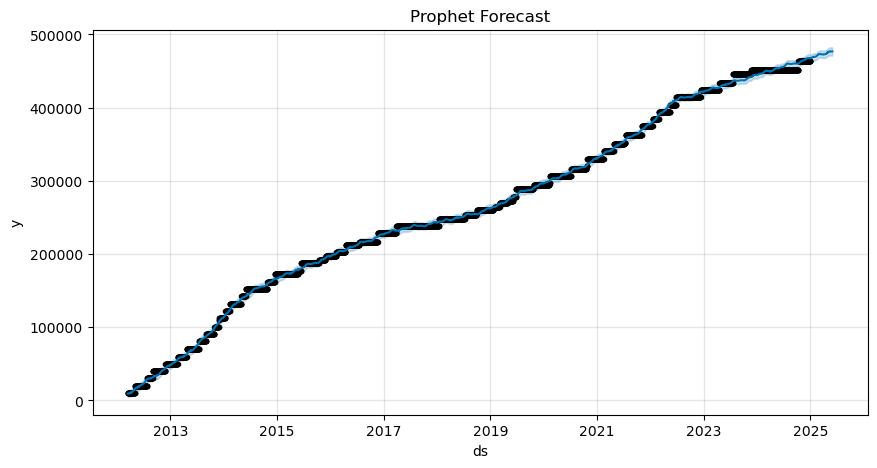

Working on rm_id: 2125.0


02:41:48 - cmdstanpy - INFO - Chain [1] start processing
02:41:53 - cmdstanpy - INFO - Chain [1] done processing


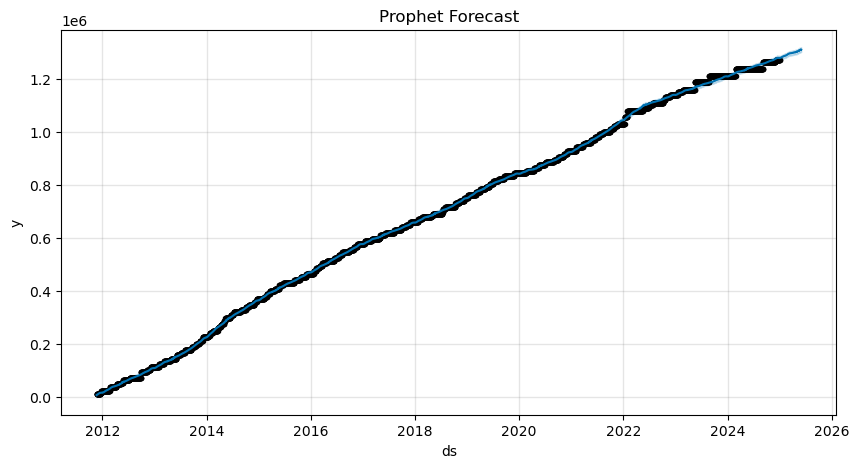

Working on rm_id: 2129.0


02:41:56 - cmdstanpy - INFO - Chain [1] start processing
02:42:02 - cmdstanpy - INFO - Chain [1] done processing


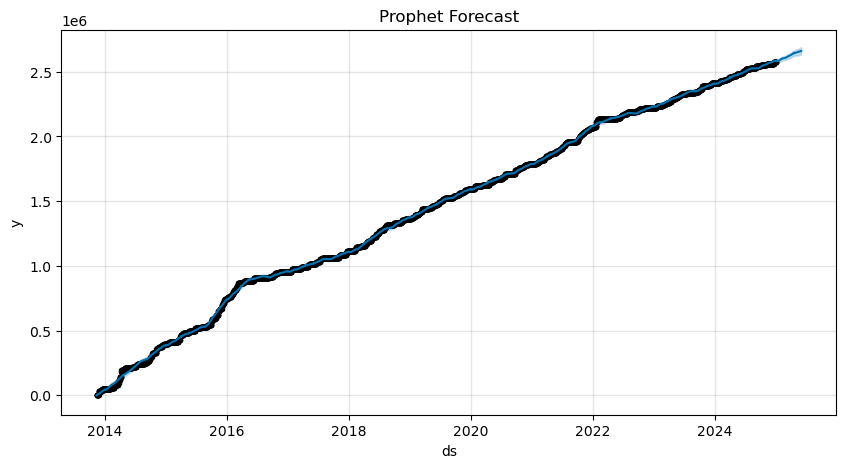

Working on rm_id: 2130.0


02:42:05 - cmdstanpy - INFO - Chain [1] start processing
02:42:15 - cmdstanpy - INFO - Chain [1] done processing


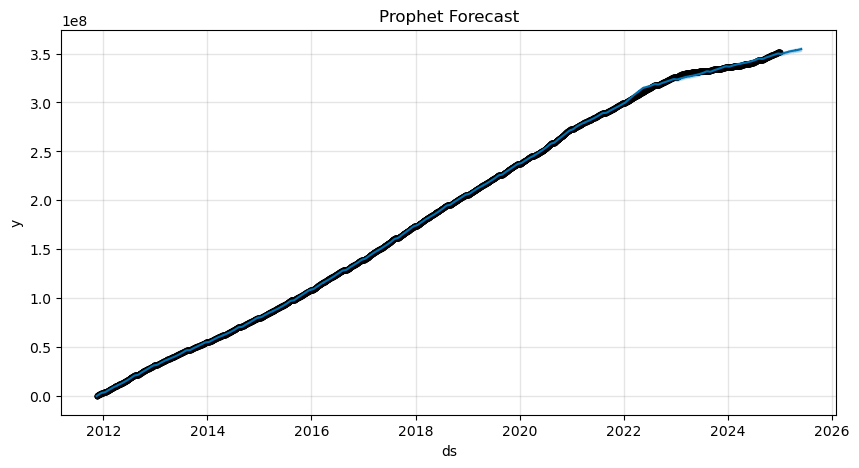

Working on rm_id: 2131.0


02:42:21 - cmdstanpy - INFO - Chain [1] start processing
02:42:28 - cmdstanpy - INFO - Chain [1] done processing


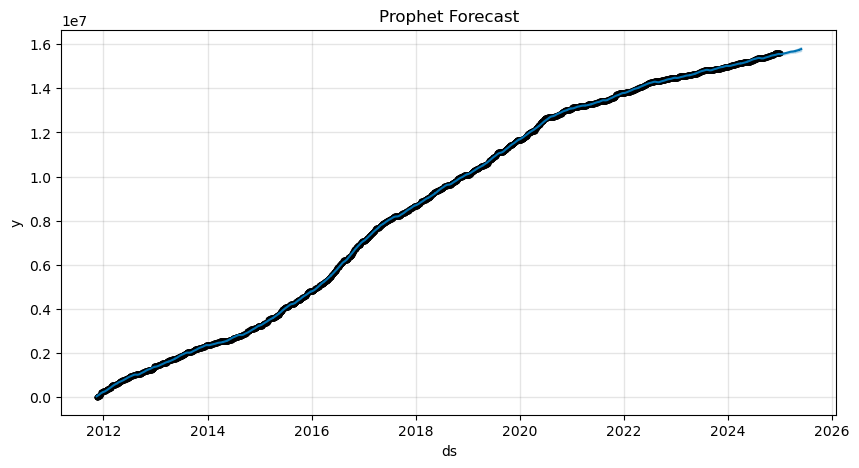

Working on rm_id: 2132.0


02:42:31 - cmdstanpy - INFO - Chain [1] start processing
02:42:39 - cmdstanpy - INFO - Chain [1] done processing


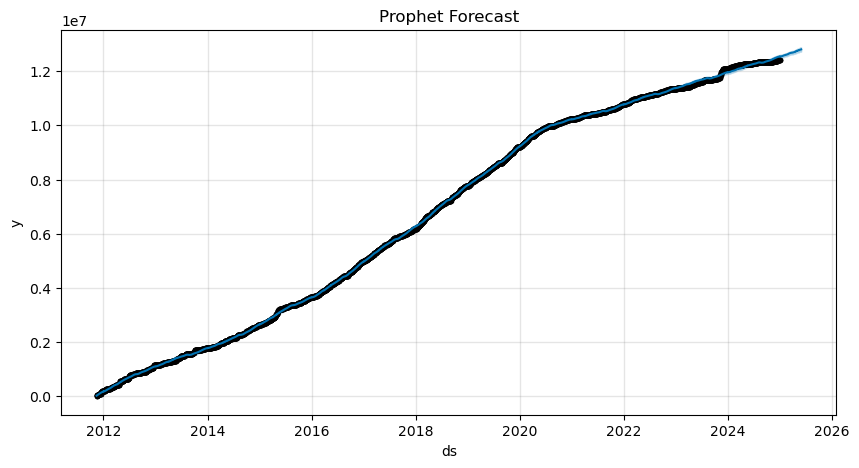

Working on rm_id: 2133.0


02:42:43 - cmdstanpy - INFO - Chain [1] start processing
02:42:51 - cmdstanpy - INFO - Chain [1] done processing


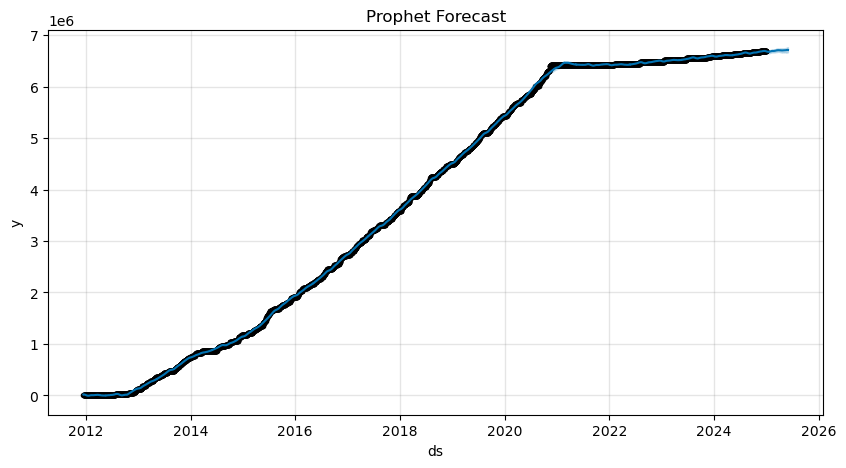

Working on rm_id: 2134.0


02:42:55 - cmdstanpy - INFO - Chain [1] start processing
02:43:06 - cmdstanpy - INFO - Chain [1] done processing


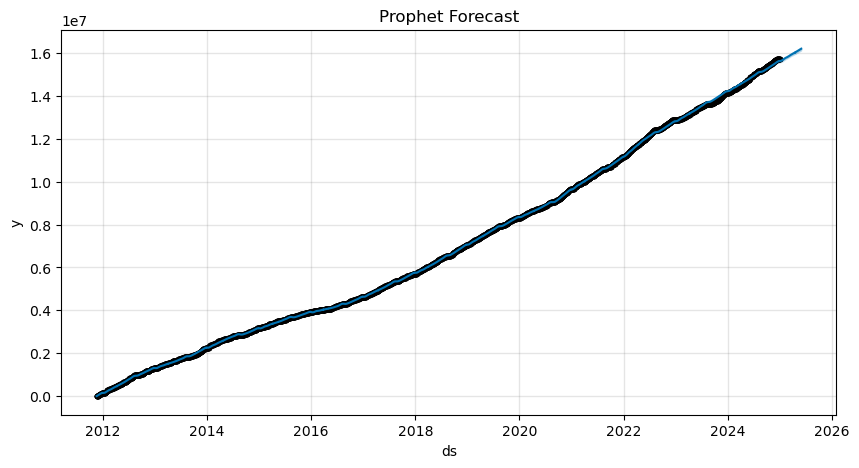

Working on rm_id: 2135.0


02:43:12 - cmdstanpy - INFO - Chain [1] start processing
02:43:26 - cmdstanpy - INFO - Chain [1] done processing


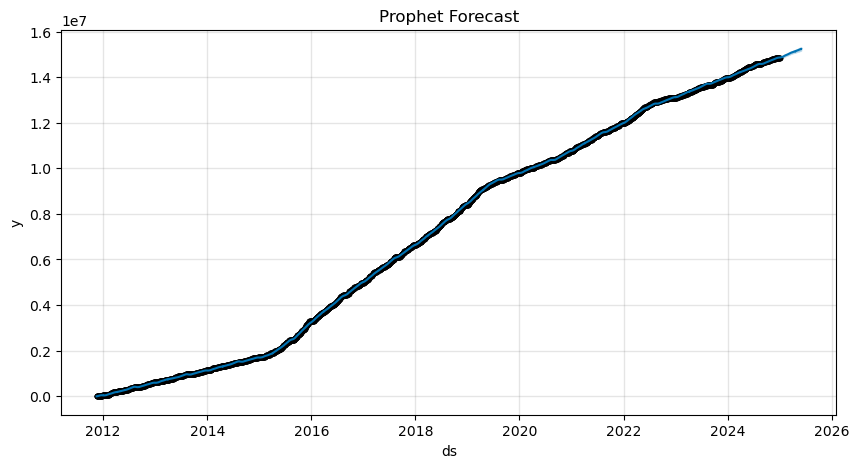

Working on rm_id: 2142.0


02:43:31 - cmdstanpy - INFO - Chain [1] start processing
02:43:39 - cmdstanpy - INFO - Chain [1] done processing


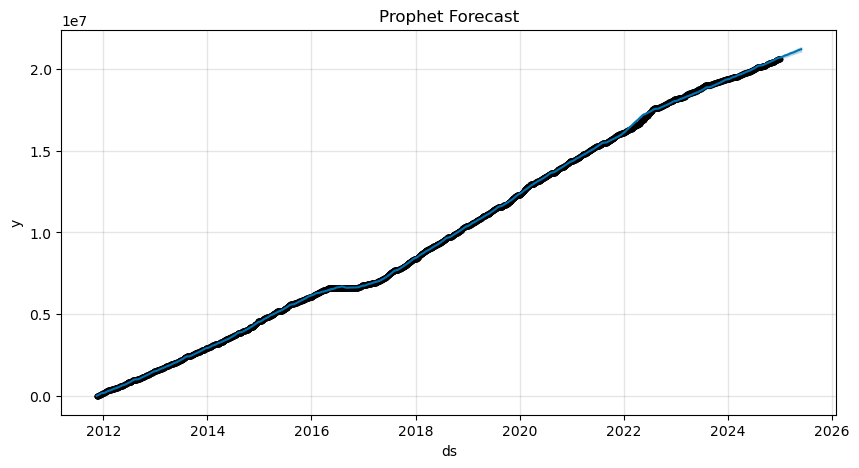

Working on rm_id: 2143.0


02:43:43 - cmdstanpy - INFO - Chain [1] start processing
02:43:48 - cmdstanpy - INFO - Chain [1] done processing


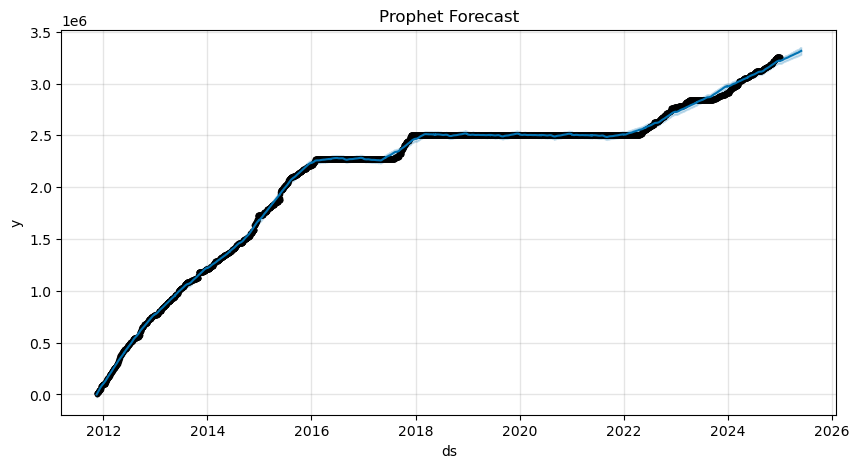

Working on rm_id: 2144.0


02:43:51 - cmdstanpy - INFO - Chain [1] start processing
02:43:59 - cmdstanpy - INFO - Chain [1] done processing


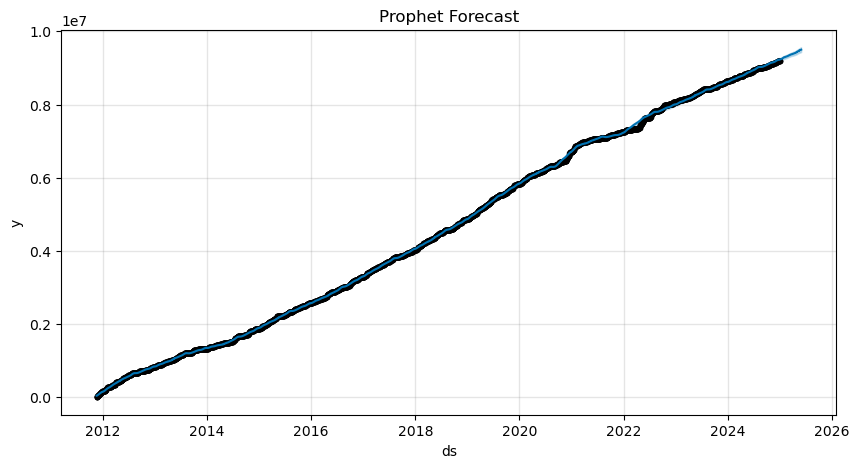

Working on rm_id: 2145.0


02:44:03 - cmdstanpy - INFO - Chain [1] start processing
02:44:14 - cmdstanpy - INFO - Chain [1] done processing


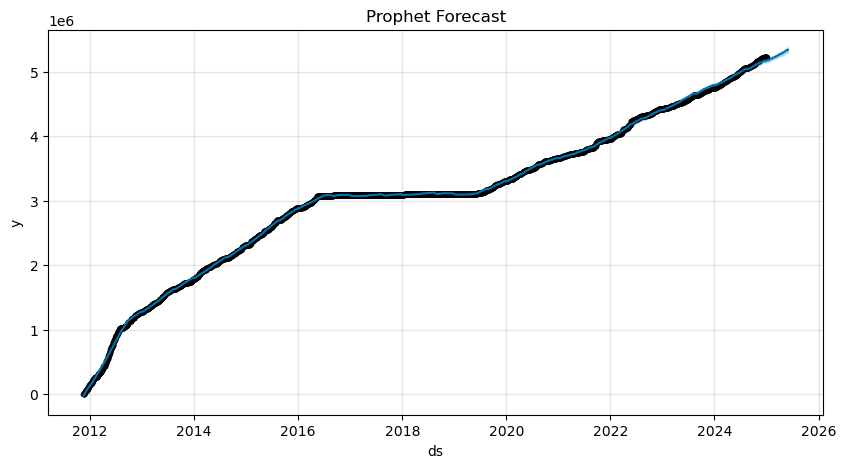

Working on rm_id: 2161.0


02:44:20 - cmdstanpy - INFO - Chain [1] start processing
02:44:26 - cmdstanpy - INFO - Chain [1] done processing


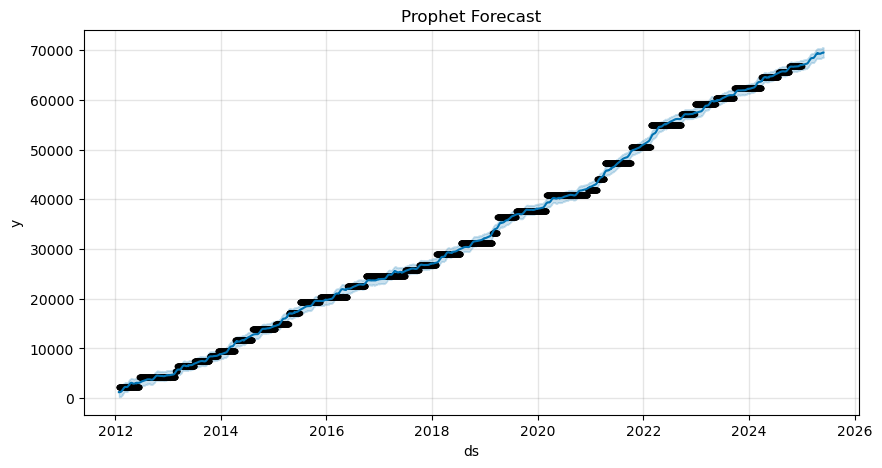

Working on rm_id: 2741.0


02:44:29 - cmdstanpy - INFO - Chain [1] start processing
02:44:31 - cmdstanpy - INFO - Chain [1] done processing


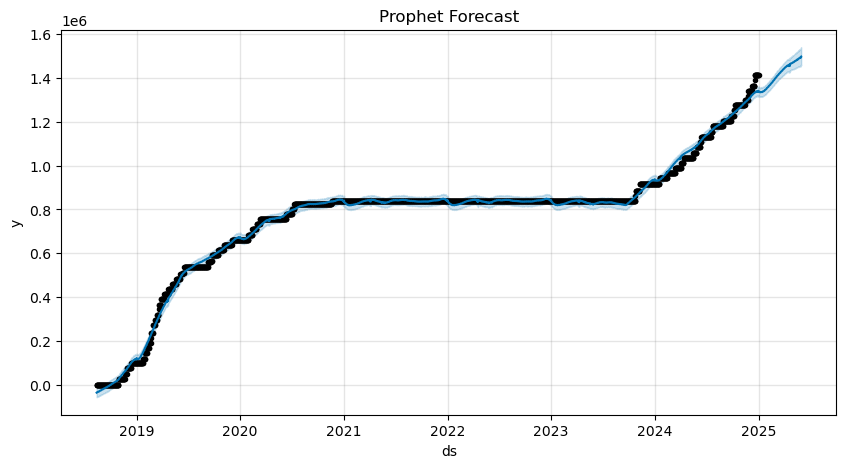

Working on rm_id: 3122.0


02:44:33 - cmdstanpy - INFO - Chain [1] start processing
02:44:35 - cmdstanpy - INFO - Chain [1] done processing


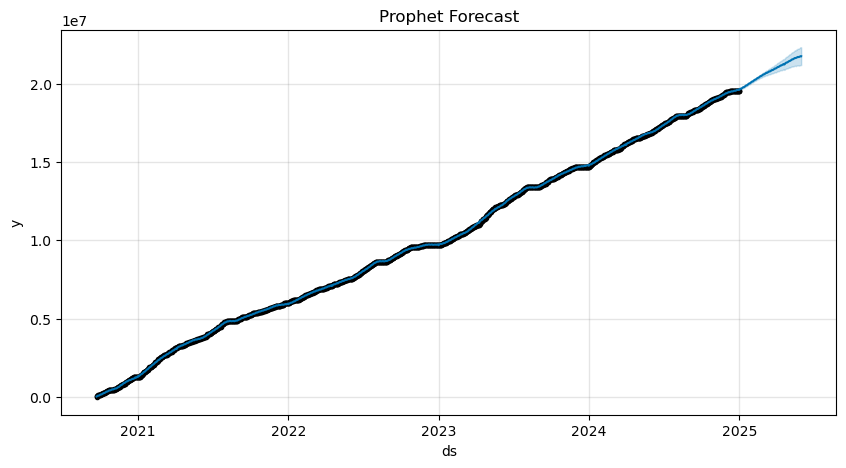

Working on rm_id: 3123.0


02:44:37 - cmdstanpy - INFO - Chain [1] start processing
02:44:39 - cmdstanpy - INFO - Chain [1] done processing


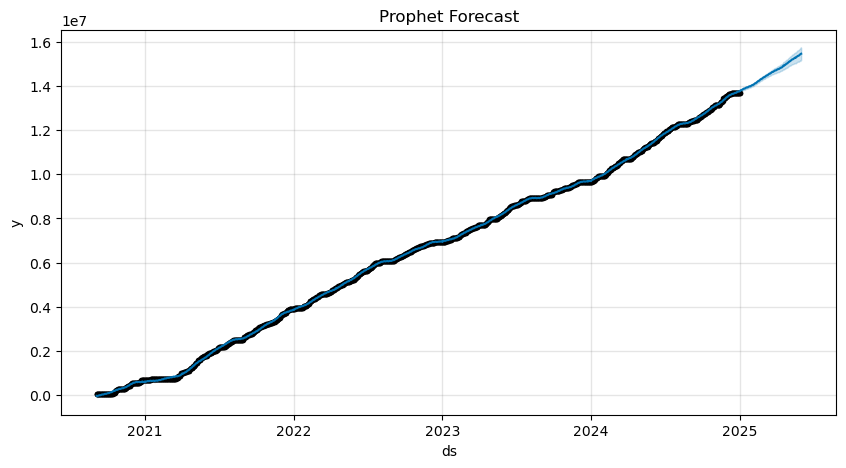

Working on rm_id: 3124.0


02:44:41 - cmdstanpy - INFO - Chain [1] start processing
02:44:43 - cmdstanpy - INFO - Chain [1] done processing


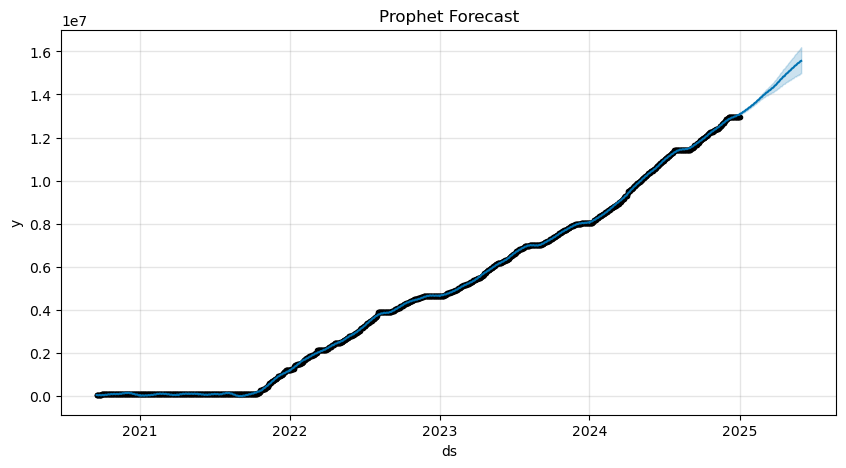

Working on rm_id: 3125.0


02:44:44 - cmdstanpy - INFO - Chain [1] start processing
02:44:46 - cmdstanpy - INFO - Chain [1] done processing


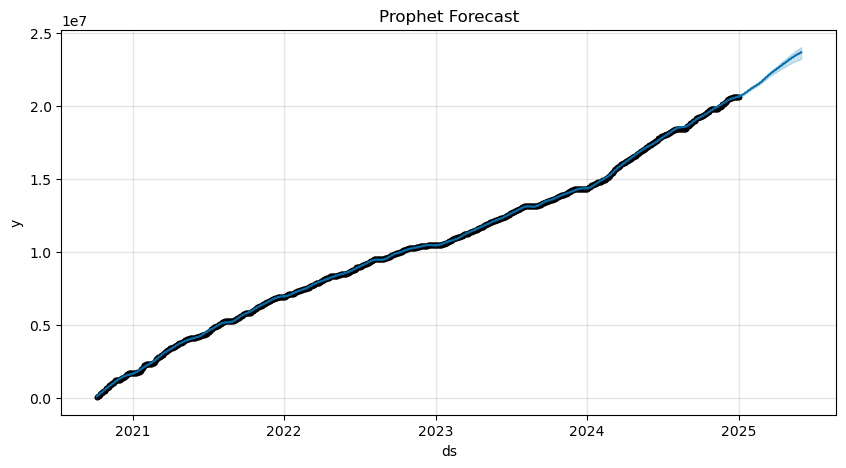

Working on rm_id: 3126.0


02:44:48 - cmdstanpy - INFO - Chain [1] start processing
02:44:50 - cmdstanpy - INFO - Chain [1] done processing


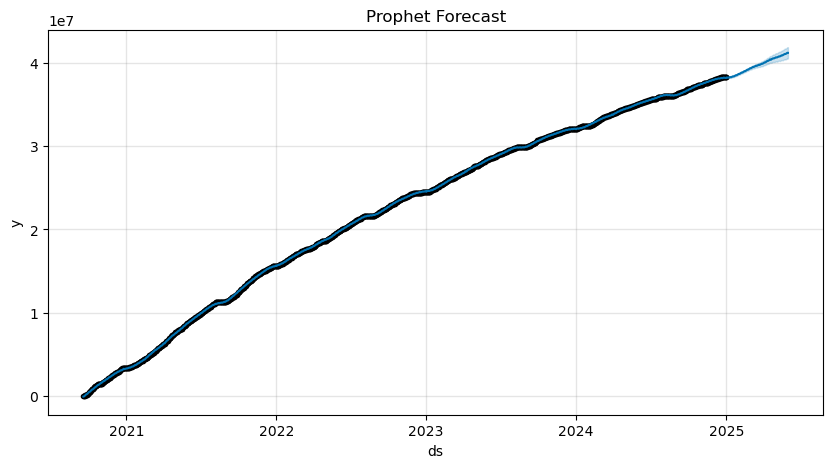

Working on rm_id: 3282.0


02:44:52 - cmdstanpy - INFO - Chain [1] start processing
02:44:53 - cmdstanpy - INFO - Chain [1] done processing


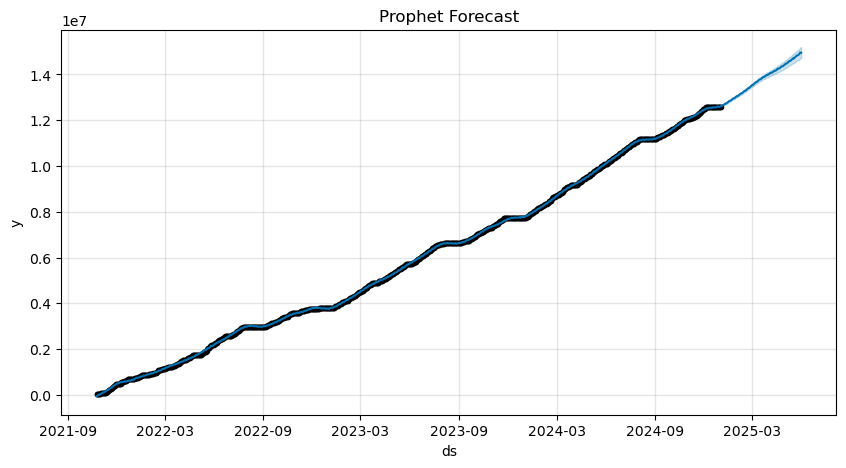

Working on rm_id: 3362.0


02:44:54 - cmdstanpy - INFO - Chain [1] start processing
02:44:54 - cmdstanpy - INFO - Chain [1] done processing


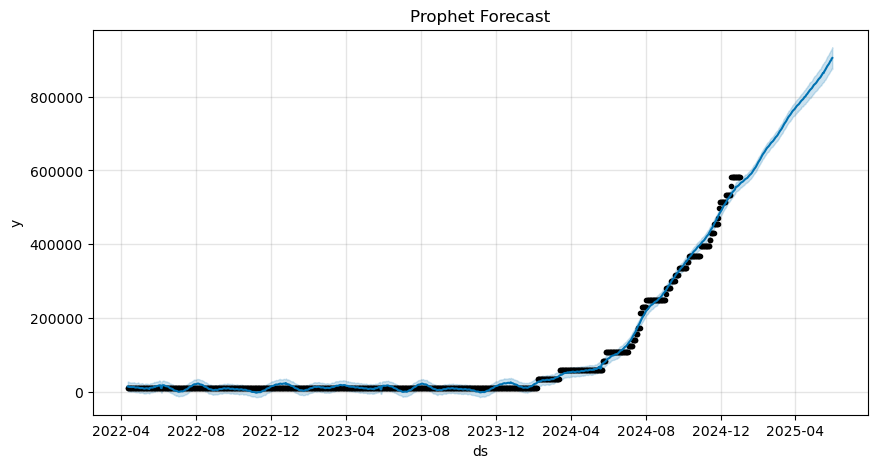

Working on rm_id: 3381.0


02:44:56 - cmdstanpy - INFO - Chain [1] start processing
02:44:56 - cmdstanpy - INFO - Chain [1] done processing


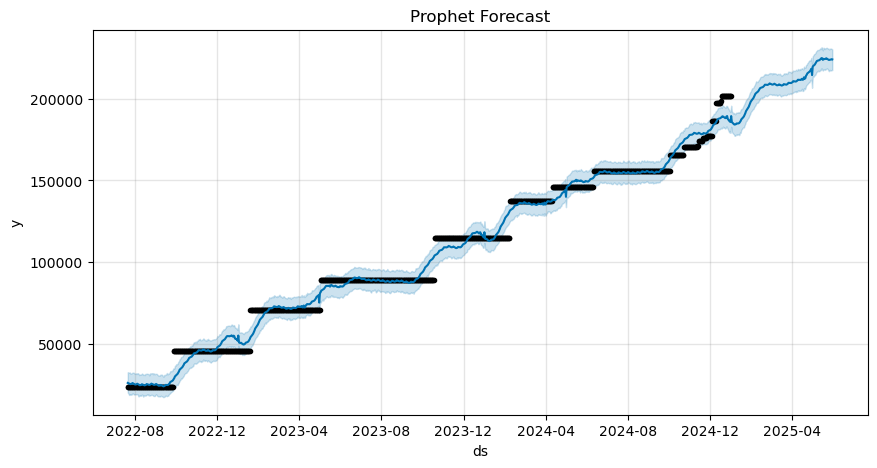

Working on rm_id: 3421.0


02:44:58 - cmdstanpy - INFO - Chain [1] start processing
02:44:58 - cmdstanpy - INFO - Chain [1] done processing


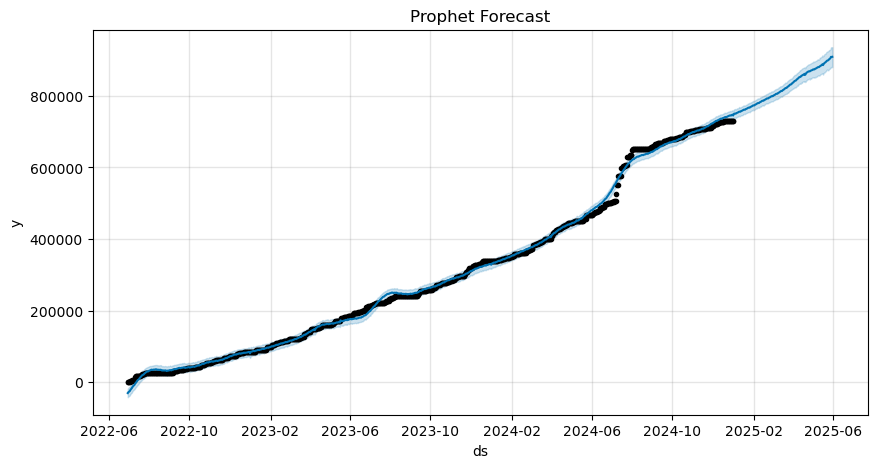

Working on rm_id: 3781.0


02:44:59 - cmdstanpy - INFO - Chain [1] start processing
02:44:59 - cmdstanpy - INFO - Chain [1] done processing


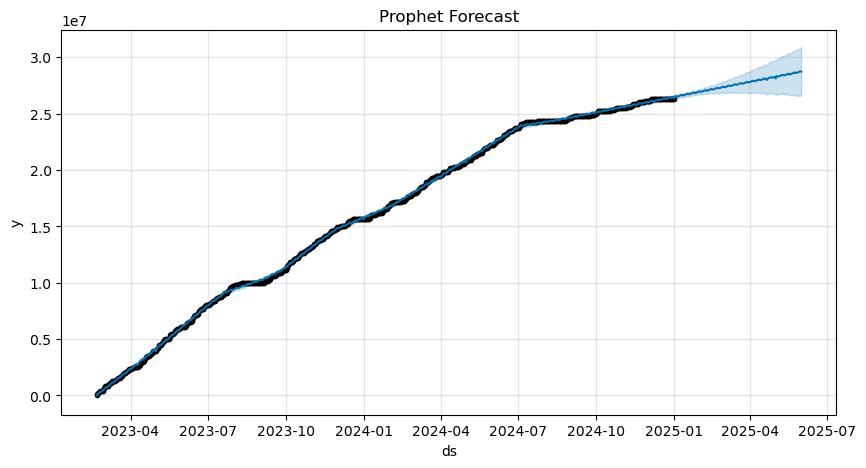

Working on rm_id: 3865.0


02:45:01 - cmdstanpy - INFO - Chain [1] start processing
02:45:01 - cmdstanpy - INFO - Chain [1] done processing


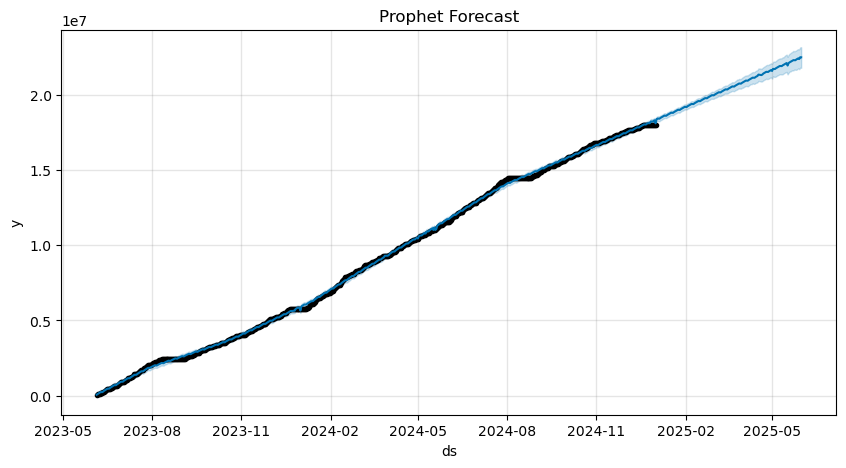

Working on rm_id: 3883.0


02:45:02 - cmdstanpy - INFO - Chain [1] start processing
02:45:03 - cmdstanpy - INFO - Chain [1] done processing


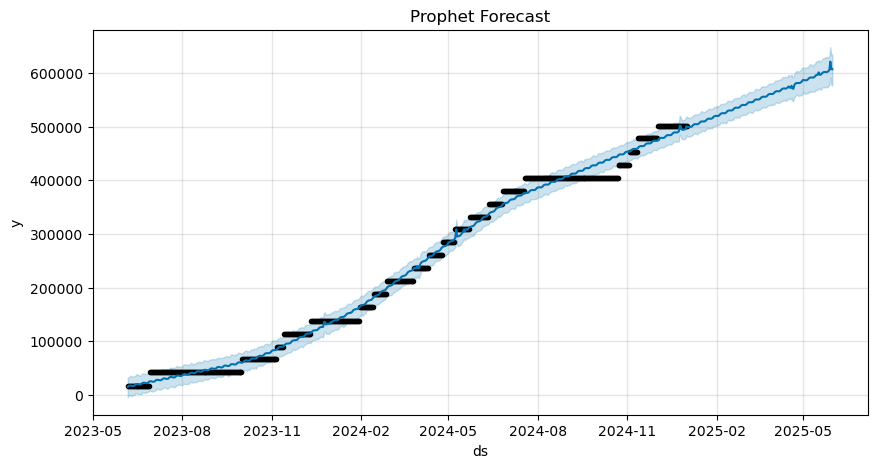

Working on rm_id: 3901.0


02:45:04 - cmdstanpy - INFO - Chain [1] start processing
02:45:04 - cmdstanpy - INFO - Chain [1] done processing


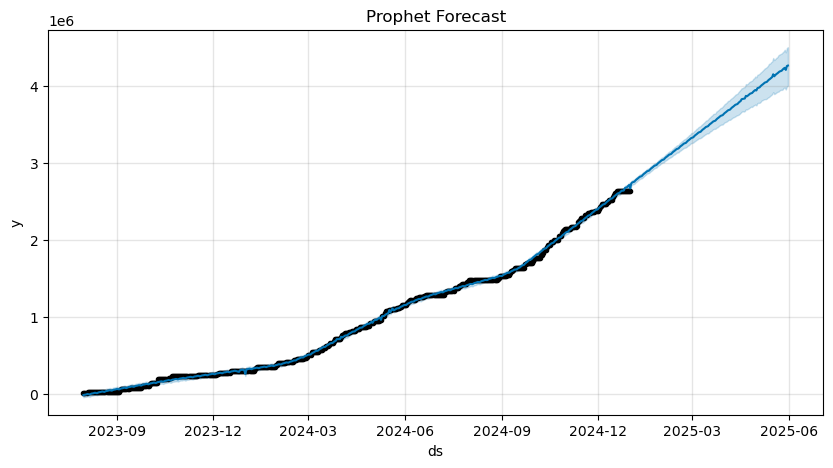

Working on rm_id: 4222.0


02:45:05 - cmdstanpy - INFO - Chain [1] start processing
02:45:05 - cmdstanpy - INFO - Chain [1] done processing


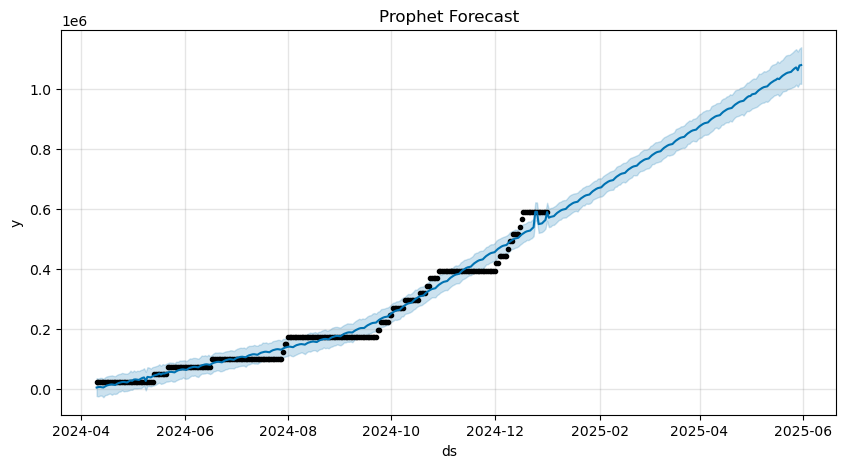

Working on rm_id: 4263.0


02:45:06 - cmdstanpy - INFO - Chain [1] start processing
02:45:06 - cmdstanpy - INFO - Chain [1] done processing


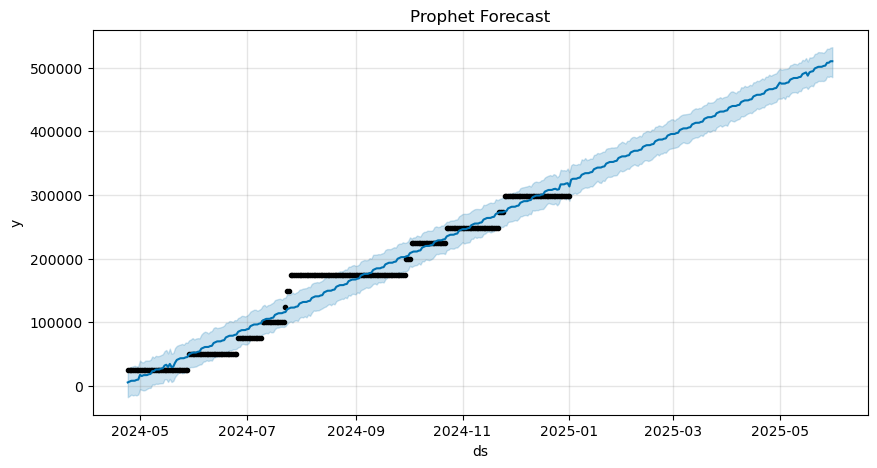

In [52]:
from prophet.serialize import model_to_json, model_from_json

from pandas.tseries.holiday import AbstractHolidayCalendar, Holiday
from pandas.tseries.offsets import Day

from prophet.make_holidays import make_holidays_df


def is_holiday(date, holiday_df):
    return date in set(holiday_df['ds'])


results = []
for rm_id, group in df.groupby('rm_id'):
    print(f"Working on rm_id: {rm_id}")
    tmp = group.rename(columns={"date": "ds", "cum_weight": "y"})

    first_active = tmp.loc[tmp['y'] > 0, 'ds'].iloc[0]

    tmp = tmp[tmp['ds'] >= first_active].reset_index(drop=True)

    tmp['working_days'] = (tmp['ds'].dt.weekday < 5).astype(int)

    norway_holidays = make_holidays_df(year_list=tmp['ds'].dt.year.unique(), country='NO')
    
    m = Prophet(
        weekly_seasonality = True,
        changepoint_prior_scale = 0.01,
        seasonality_mode = 'additive',
        holidays = norway_holidays,
        )
    
    
    m.add_regressor('working_days')
   
    m.fit(tmp)

    future = m.make_future_dataframe(periods=150, freq="D")
    future['working_days'] = future['ds'].dt.weekday < 5
    future['working_days'] = future['working_days'].astype(int)
    future['annual_quantity'] = tmp.iloc[-1]['annual_quantity']
  

    forecast = m.predict(future)
  

    fig, ax = plt.subplots(figsize=(10, 5))
    fig = m.plot(forecast, ax=ax)
    ax.set_title('Prophet Forecast')
    plt.show()
    
    forecast['rm_id'] = rm_id
    forecast['annual_quantity'] = tmp.iloc[-1]['annual_quantity']
    results.append(forecast[['ds', 'rm_id','annual_quantity', 'yhat','yhat_lower']])
    
final = pd.concat(results)

final = final.merge(df[['rm_id', 'date', 'cum_weight']], left_on=['rm_id', 'ds'], right_on=['rm_id', 'date'], how='left')
final = final.drop(columns=['date'])
final = final.rename(columns={'cum_weight': 'y'})


In [53]:
print(final[final['ds']>'2025-05-30']) #just to see the final prediction for each rm_id, so that everything works

              ds   rm_id  annual_quantity          yhat    yhat_lower   y
4825  2025-05-31  2123.0          10000.0  4.767995e+05  4.712135e+05 NaN
9766  2025-05-31  2125.0          15659.0  1.309305e+06  1.300600e+06 NaN
13984 2025-05-31  2129.0              0.0  2.660561e+06  2.633243e+06 NaN
18931 2025-05-31  2130.0       11290000.0  3.545996e+08  3.527862e+08 NaN
23879 2025-05-31  2131.0        1045000.0  1.577919e+07  1.570339e+07 NaN
28827 2025-05-31  2132.0         725000.0  1.280494e+07  1.272646e+07 NaN
33744 2025-05-31  2133.0         410000.0  6.711665e+06  6.667197e+06 NaN
38689 2025-05-31  2134.0        1080000.0  1.619074e+07  1.612294e+07 NaN
43635 2025-05-31  2135.0         830000.0  1.524290e+07  1.517384e+07 NaN
48582 2025-05-31  2142.0        1045000.0  2.119179e+07  2.105479e+07 NaN
53529 2025-05-31  2143.0         725000.0  3.315111e+06  3.278366e+06 NaN
58473 2025-05-31  2144.0         410000.0  9.499537e+06  9.434606e+06 NaN
63420 2025-05-31  2145.0        108000

In [54]:
future_2025 = final[(final['ds'] >= '2025-01-02') & (final['ds'] <= '2025-05-31')].copy()

n_days = 150
preds = future_2025["yhat"].values.copy()

for start in range(0, len(preds), n_days):
    end = start + n_days
    preds[start:end] = np.maximum.accumulate(preds[start:end])
    
future_2025["yhat_corr"] = preds

preds = future_2025['yhat_corr'].values.copy()
predicted_weight = np.zeros_like(preds)

for start in range(0, len(preds), n_days):
    end = start + n_days
    base = preds[start]                    
    predicted_weight[start:end] = preds[start:end] - base

future_2025['predicted_weight'] = predicted_weight


In [55]:
print(future_2025[['ds', 'yhat','predicted_weight' ,'yhat_corr', 'rm_id']])
print(future_2025['predicted_weight'].value_counts())
plt.figure(figsize=(12, 6))

for rm_id, group in future_2025.groupby('rm_id'):
    plt.plot(group['ds'], group['predicted_weight'], marker='o', label=f'rm_id: {rm_id}')

plt.xlabel("Data")
plt.ylabel("yhat_corr (corrected_cum_weight)")
plt.title("yhat_corr evolution for each rm_id in 2025")
plt.legend()
out4 = "fig/yhat2025.png"
plt.tight_layout()
plt.savefig(out4, dpi=200)
plt.close()

print(f"Saved {out4}")


              ds           yhat  predicted_weight      yhat_corr   rm_id
4676  2025-01-02  467578.965728          0.000000  467578.965728  2123.0
4677  2025-01-03  467672.569724         93.603996  467672.569724  2123.0
4678  2025-01-04  467636.681046         93.603996  467672.569724  2123.0
4679  2025-01-05  467607.409372         93.603996  467672.569724  2123.0
4680  2025-01-06  467798.514460        219.548732  467798.514460  2123.0
...          ...            ...               ...            ...     ...
87703 2025-05-27  503308.390856     179270.052386  503308.390856  4263.0
87704 2025-05-28  507669.488686     183631.150216  507669.488686  4263.0
87705 2025-05-29  507859.632156     183821.293685  507859.632156  4263.0
87706 2025-05-30  510214.353015     186176.014545  510214.353015  4263.0
87707 2025-05-31  510203.769952     186176.014545  510214.353015  4263.0

[4500 rows x 5 columns]
0.000000         67
24897.978023     55
5732.395799      40
23684.549241     28
380.550747       27

In [56]:
future_2025 = future_2025[(future_2025['ds'] >= '2025-01-02')]

q_min = future_2025['annual_quantity'].min()
q_max = future_2025['annual_quantity'].max()
future_2025['annual_quantity_norm'] = (future_2025['annual_quantity'] - q_min) / (q_max - q_min)


future_2025['shrink_factor'] = 0.6 + 0.4 * future_2025['annual_quantity_norm']


future_2025['predicted_weight'] = (
    future_2025['predicted_weight'] * future_2025['shrink_factor']
)
print(future_2025)
future_2025 = future_2025[['ds','predicted_weight','rm_id']]
future_2025 = future_2025.rename(columns={'ds': 'date'})

              ds   rm_id  annual_quantity           yhat     yhat_lower   y  \
4676  2025-01-02  2123.0          10000.0  467578.965728  463201.465052 NaN   
4677  2025-01-03  2123.0          10000.0  467672.569724  463272.935330 NaN   
4678  2025-01-04  2123.0          10000.0  467636.681046  463143.662220 NaN   
4679  2025-01-05  2123.0          10000.0  467607.409372  462882.966097 NaN   
4680  2025-01-06  2123.0          10000.0  467798.514460  462999.839491 NaN   
...          ...     ...              ...            ...            ...  ..   
87703 2025-05-27  4263.0        3000000.0  503308.390856  480737.780826 NaN   
87704 2025-05-28  4263.0        3000000.0  507669.488686  486128.063331 NaN   
87705 2025-05-29  4263.0        3000000.0  507859.632156  485552.430567 NaN   
87706 2025-05-30  4263.0        3000000.0  510214.353015  486972.669270 NaN   
87707 2025-05-31  4263.0        3000000.0  510203.769952  485137.981032 NaN   

           yhat_corr  predicted_weight  annual_quan

In [57]:
print(future_2025)

            date  predicted_weight   rm_id
4676  2025-01-02          0.000000  2123.0
4677  2025-01-03         56.195561  2123.0
4678  2025-01-04         56.195561  2123.0
4679  2025-01-05         56.195561  2123.0
4680  2025-01-06        131.807024  2123.0
...          ...               ...     ...
87703 2025-05-27     126616.421410  4263.0
87704 2025-05-28     129696.615750  4263.0
87705 2025-05-29     129830.911944  4263.0
87706 2025-05-30     131494.024799  4263.0
87707 2025-05-31     131494.024799  4263.0

[4500 rows x 3 columns]


## Submission file creation

In [58]:
mapping = pd.read_csv("prediction_mapping.csv")
mapping["forecast_start_date"] = pd.to_datetime(mapping["forecast_start_date"], utc=True)
mapping["forecast_end_date"] = pd.to_datetime(mapping["forecast_end_date"], utc=True)
mapping = mapping.rename(columns={'forecast_end_date': 'date'})
future_2025["date"] = pd.to_datetime(future_2025["date"], utc=True)

mapping = mapping.merge(
    future_2025[['rm_id', 'date', 'predicted_weight']],
    on=['rm_id', 'date'],
    how='left'
)

submission = mapping[["ID", "predicted_weight"]]


submission["predicted_weight"] = submission["predicted_weight"].fillna(0)
submission.to_csv("final_submission.csv", index=False)

print("✅ File saved")

C:\Users\Admin\AppData\Local\Temp\ipykernel_7592\1946168317.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission["predicted_weight"] = submission["predicted_weight"].fillna(0)


✅ File saved


In [59]:
print(submission)

          ID  predicted_weight
0          1               0.0
1          2               0.0
2          3               0.0
3          4               0.0
4          5               0.0
...      ...               ...
30445  30446               0.0
30446  30447               0.0
30447  30448               0.0
30448  30449               0.0
30449  30450               0.0

[30450 rows x 2 columns]
